# Código inicial y carga del dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import (
 train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
 confusion_matrix, ConfusionMatrixDisplay,
 accuracy_score, precision_score, recall_score,
 classification_report
)
RANDOM_STATE = 42
df = pd.read_csv("liga_mx_1000000_registros.csv")
print("Dimensión:", df.shape)
display(df.head())
print(df.dtypes)
print(df.isnull().sum())
print("Memoria MB:",
 df.memory_usage(deep=True).sum()/1024**2)

Dimensión: (1000000, 10)


,id_registro,equipo,año_creacion,ciudad,estadio,campeonatos,estimacion_aficionados,jugador_id,minuto_jugado,pases_completados
0,1,Club América,1916,CDMX,Azteca,15,12000000,JUG-8366,22,34
1,2,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-4245,63,27
2,3,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-7691,1,18
3,4,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-1453,71,27
4,5,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-6761,47,20


id_registro                int64
equipo                    object
año_creacion               int64
ciudad                    object
estadio                   object
campeonatos                int64
estimacion_aficionados     int64
jugador_id                object
minuto_jugado              int64
pases_completados          int64
dtype: object
id_registro               0
equipo                    0
año_creacion              0
ciudad                    0
estadio                   0
campeonatos               0
estimacion_aficionados    0
jugador_id                0
minuto_jugado             0
pases_completados         0
dtype: int64
Memoria MB: 273.08780097961426


La dimensión de los datos confirma que estamos trabajando con exactamente 1,000,000 de registros y 10 variables. La suma de datos nulos en ceros nos indica que el dataset está completo y no requiere imputación o eliminación de valores faltantes.

## Media, mediana, moda y desviación estándar

In [7]:
variables = ["minuto_jugado", "pases_completados"]
filas = []
for col in variables:
 filas.append({
 "Variable": col,
 "Media": df[col].mean(),
 "Mediana": df[col].median(),
 "Moda": df[col].mode().iloc[0],
 "Desviación estándar": df[col].std()
 })
resumen = pd.DataFrame(filas)
display(resumen)

,Variable,Media,Mediana,Moda,Desviación estándar
0,minuto_jugado,45.025271,45.0,32,25.669992
1,pases_completados,24.995078,25.0,25,5.001682


La media nos indica el valor promedio, mientras que la mediana refleja el valor exactamente en el centro cuando los datos se ordenan. La moda nos muestra el número que más se repite. Si la media y la mediana son casi idénticas (como en pases_completados), sugiere que los datos se distribuyen de manera muy simétrica, sin estar sesgados. La desviación estándar nos dice qué tan alejados suelen estar los datos respecto a ese promedio.



## IQR y posibles outliers

In [8]:
col = "pases_completados"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR
outliers = df[(df[col] < LI) | (df[col] > LS)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", LI)
print("Límite superior:", LS)
print("Posibles outliers:", len(outliers))
print("Porcentaje:", len(outliers)/len(df)*100)

Q1: 22.0
Q3: 28.0
IQR: 6.0
Límite inferior: 13.0
Límite superior: 37.0
Posibles outliers: 12276
Porcentaje: 1.2276


Un "outlier" o valor atípico estadístico no es automáticamente un error de captura o un dato corrupto. En el fútbol, es perfectamente posible y real que un jugador dispute muy pocos minutos (por ejemplo, si es expulsado o entra de cambio al final) o que complete una cantidad inusualmente alta de pases. Se decidió conservar estos datos porque representan escenarios atípicos pero reales que el modelo debe conocer.

## Boxplot

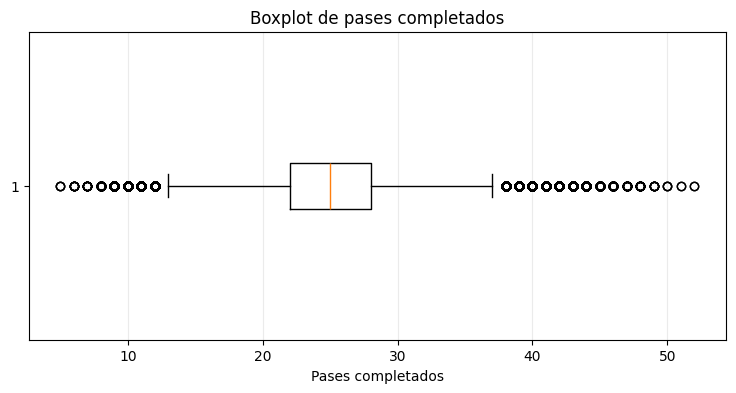

In [9]:
plt.figure(figsize=(9,4))
plt.boxplot(df["pases_completados"].dropna(), vert=False)
plt.title("Boxplot de pases completados")
plt.xlabel("Pases completados")
plt.grid(axis="x", alpha=0.25)
plt.show()

La "caja" central agrupa el 50% de los datos (desde el cuartil 1 al cuartil 3), y la línea interior es la mediana. Los "bigotes" marcan los límites de lo que consideramos normal basándonos en el IQR, y todos los puntos que se dibujan fuera de esos bigotes son los outliers que calculamos antes.

##  Nube de puntos: cada clase con un color

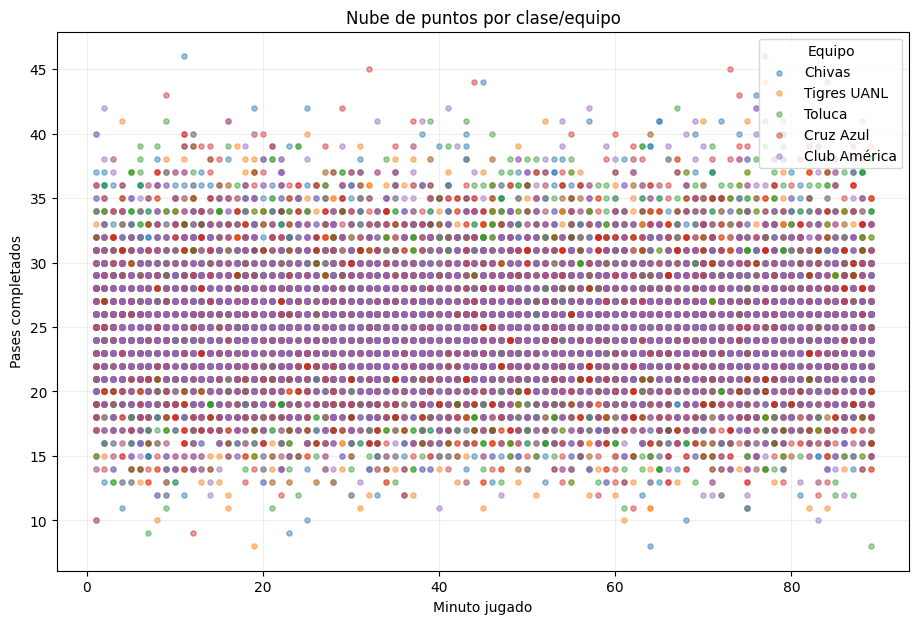

In [10]:
muestra = df.sample(n=20000, random_state=RANDOM_STATE)
equipos = muestra["equipo"].unique()
cmap = plt.get_cmap("tab10")
plt.figure(figsize=(11,7))
for i, equipo in enumerate(equipos):
 parte = muestra[muestra["equipo"] == equipo]
 plt.scatter(
 parte["minuto_jugado"],
 parte["pases_completados"],
 s=14,
 alpha=0.45,
 color=cmap(i),
 label=equipo
 )
plt.title("Nube de puntos por clase/equipo")
plt.xlabel("Minuto jugado")
plt.ylabel("Pases completados")
plt.legend(title="Equipo")
plt.grid(alpha=0.20)
plt.show()

Los colores nos ayudan a ver a los equipos (clases). Si los puntos de todos los colores están altamente superpuestos o mezclados, significa que no existe una separación evidente entre los equipos basándonos solo en minutos jugados y pases completados, lo cual hará que la clasificación sea difícil.

## Campana de Gauss como referencia

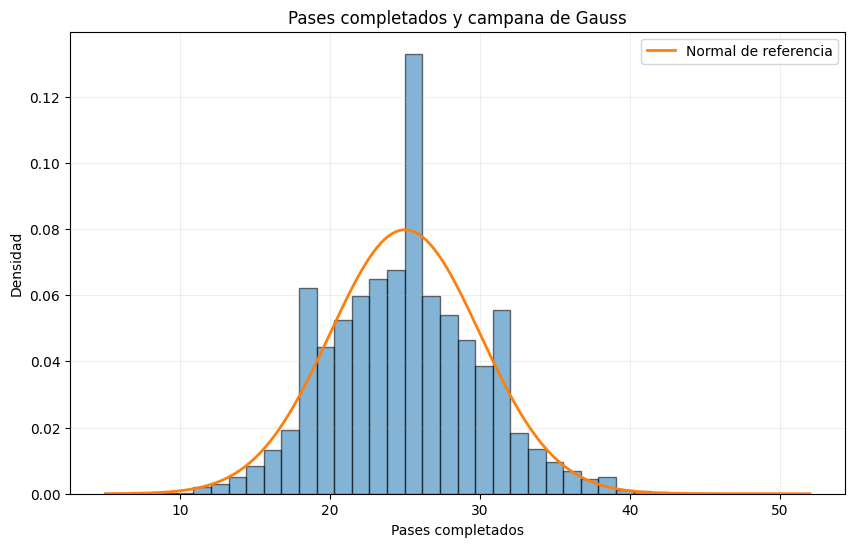

In [11]:
x = df["pases_completados"].dropna()
mu = x.mean()
sigma = x.std()
plt.figure(figsize=(10,6))
_, bins, _ = plt.hist(
 x, bins=40, density=True,
 alpha=0.55, edgecolor="black"
)
xx = np.linspace(bins.min(), bins.max(), 400)
gauss = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(
 -0.5*((xx-mu)/sigma)**2
)
plt.plot(xx, gauss, linewidth=2,
 label="Normal de referencia")
plt.title("Pases completados y campana de Gauss")
plt.xlabel("Pases completados")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

El histograma no empata a la perfección con la campana teórica. Aunque la distribución pueda verse centrada, si las "colas" (los extremos) de nuestro histograma son más gruesas o el pico central es distinto al de la línea teórica, concluimos que la variable se aproxima a la normalidad pero no es perfectamente normal.

## X, y y problema de clasificación

In [12]:
df_modelo = df.copy()
df_modelo["objetivo"] = (
 df_modelo["equipo"] == "Toluca"
).astype(int)
X = df_modelo[[
 "minuto_jugado",
 "pases_completados"
]]
y = df_modelo["objetivo"]
print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())
print(y.value_counts(normalize=True))

X: (1000000, 2)
y: (1000000,)
objetivo
0    799646
1    200354
Name: count, dtype: int64
objetivo
0    0.799646
1    0.200354
Name: proportion, dtype: float64


Excluimos campos como "equipo", "estadio", "año_creacion", "ciudad" o identificadores porque revelarían la respuesta. El objetivo es que el algoritmo aprenda patrones de rendimiento (pases y minutos), no que memorice el nombre del estadio asociado al Toluca.

## Entrenamiento y prueba

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.20,
 random_state=RANDOM_STATE,
 stratify=y
)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Entrenamiento: (800000, 2)
Prueba: (200000, 2)
objetivo
0    0.799646
1    0.200354
Name: proportion, dtype: float64
objetivo
0    0.799645
1    0.200355
Name: proportion, dtype: float64


Separamos un 20% de datos para prueba porque evaluar al modelo con los mismos datos que usó para entrenar haría que pareciera perfecto por memorización, no por capacidad de generalizar. Se usa stratify para asegurar que el porcentaje tan bajo de registros del "Toluca" se respete proporcionalmente tanto en el examen como en el entrenamiento

## Modelo 1: Árbol de Decisión

              precision    recall  f1-score   support

 Otro equipo       0.80      1.00      0.89    159929
      Toluca       0.00      0.00      0.00     40071

    accuracy                           0.80    200000
   macro avg       0.40      0.50      0.44    200000
weighted avg       0.64      0.80      0.71    200000



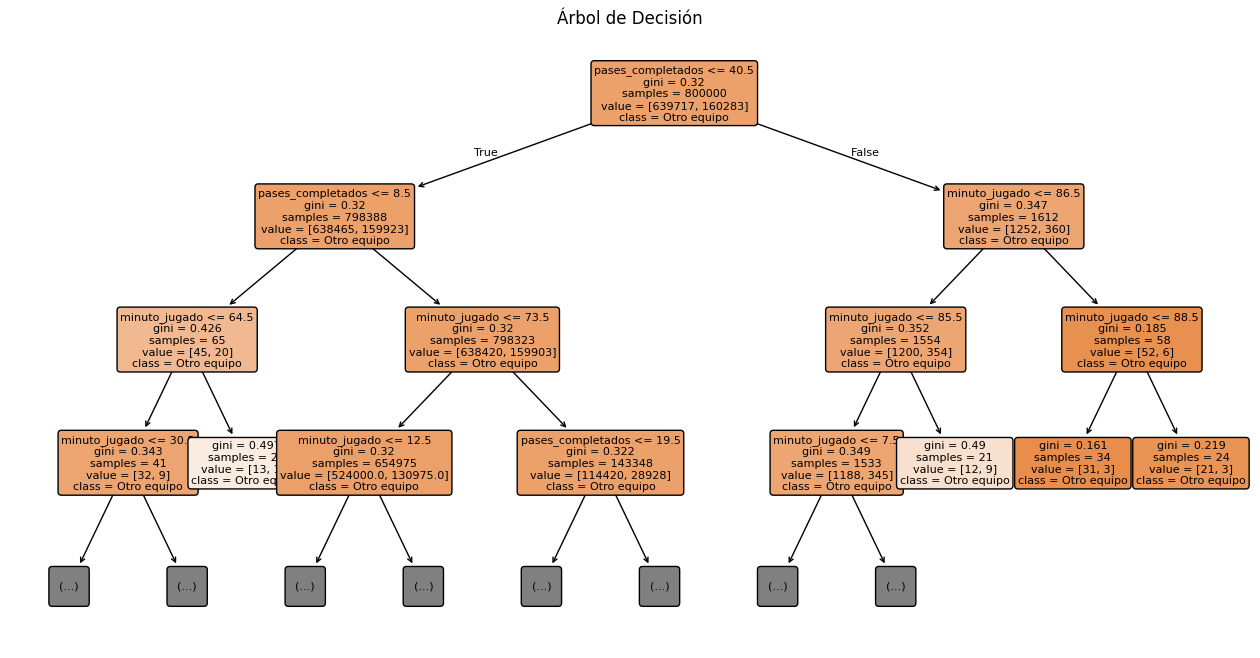

In [15]:
arbol = DecisionTreeClassifier(
 max_depth=5,
 min_samples_leaf=20,
 random_state=RANDOM_STATE
)
arbol.fit(X_train, y_train)
pred_arbol = arbol.predict(X_test)
print(classification_report(
 y_test, pred_arbol,
 target_names=["Otro equipo", "Toluca"],
 zero_division=0
))
plt.figure(figsize=(16,8))
plot_tree(
 arbol,
 feature_names=X.columns,
 class_names=["Otro equipo", "Toluca"],
 filled=True, rounded=True,
 max_depth=3, fontsize=8
)
plt.title("Árbol de Decisión")
plt.show()

Un nodo hace una pregunta (ej. ¿pases < 20?), la rama bifurca los datos según la respuesta, y la hoja entrega la predicción final (Toluca u Otro). Limitar la profundidad máxima a 5 es crucial para evitar que el árbol crezca demasiado y empiece a memorizar ruido (sobreajuste/overfitting).

## Modelo 2: KNN / vecinos más cercanos

In [16]:
knn = Pipeline([
 ("scaler", StandardScaler()),
 ("modelo", KNeighborsClassifier(
 n_neighbors=7,
 weights="distance",
 n_jobs=-1
 ))
])
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
print(classification_report(
 y_test, pred_knn,
 target_names=["Otro equipo", "Toluca"],
 zero_division=0
))

              precision    recall  f1-score   support

 Otro equipo       0.80      0.97      0.88    159929
      Toluca       0.20      0.03      0.05     40071

    accuracy                           0.78    200000
   macro avg       0.50      0.50      0.46    200000
weighted avg       0.68      0.78      0.71    200000



Clasifica un nuevo dato revisando las clases de sus vecinos más cercanos espacialmente. Es indispensable utilizar un escalador (StandardScaler) porque, al basarse en distancias matemáticas, variables con escalas muy grandes dominarían el cálculo sobre variables con valores pequeños.

##  Matriz de confusión y VP, VN, FP, FN



 Árbol de Decisión
VN = 159929
FP = 0
FN = 40071
VP = 0
Accuracy = 0.799645
Precision = 0.0
Recall = 0.0


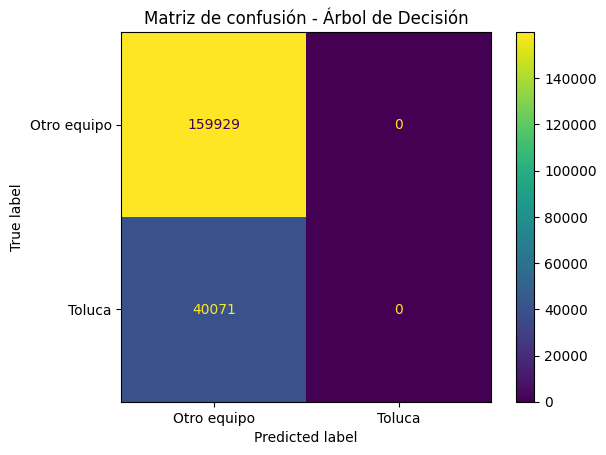


 KNN
VN = 155830
FP = 4099
FN = 39021
VP = 1050
Accuracy = 0.7844
Precision = 0.20392309186249757
Recall = 0.026203488807366924


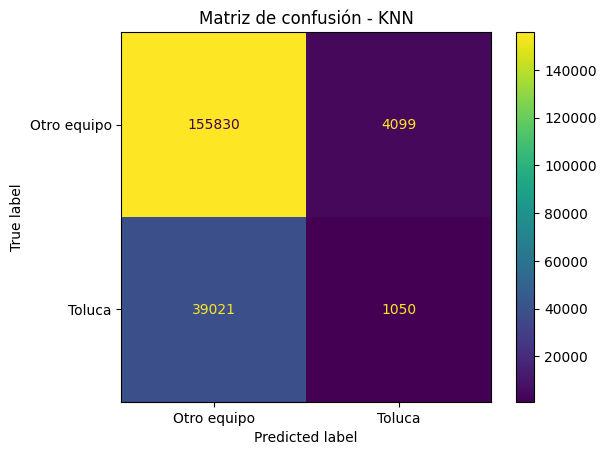

,Modelo,Accuracy,Precision,Recall,VP,VN,FP,FN
0,Árbol de Decisión,0.799645,0.000000,0.000000,0,159929,0,40071
1,KNN,0.784400,0.203923,0.026203,1050,155830,4099,39021


In [17]:
def evaluar(nombre, y_real, y_pred):
 cm = confusion_matrix(y_real, y_pred, labels=[0,1])
 vn, fp, fn, vp = cm.ravel()
 acc = accuracy_score(y_real, y_pred)
 pre = precision_score(y_real, y_pred, zero_division=0)
 rec = recall_score(y_real, y_pred, zero_division=0)
 print("\n", nombre)
 print("VN =", vn)
 print("FP =", fp)
 print("FN =", fn)
 print("VP =", vp)
 print("Accuracy =", acc)
 print("Precision =", pre)
 print("Recall =", rec)
 ConfusionMatrixDisplay(
 confusion_matrix=cm,
 display_labels=["Otro equipo", "Toluca"]
 ).plot(values_format="d")
 plt.title("Matriz de confusión - " + nombre)
 plt.show()
 return {
 "Modelo": nombre,
 "Accuracy": acc,
 "Precision": pre,
 "Recall": rec,
 "VP": vp, "VN": vn,
 "FP": fp, "FN": fn
 }
r_arbol = evaluar("Árbol de Decisión",
 y_test, pred_arbol)
r_knn = evaluar("KNN",
 y_test, pred_knn)
resultados = pd.DataFrame([r_arbol, r_knn])
display(resultados)

Verdadero Positivo (VP) es cuando era Toluca y se predijo bien. Verdadero Negativo (VN) es cuando era otro equipo y se descartó bien. Falso Positivo (FP) es cuando el modelo se equivocó y señaló a otro equipo como si fuera Toluca. Falso Negativo (FN) es cuando a un jugador del Toluca no lo detectó

## Comparación gráfica de modelos

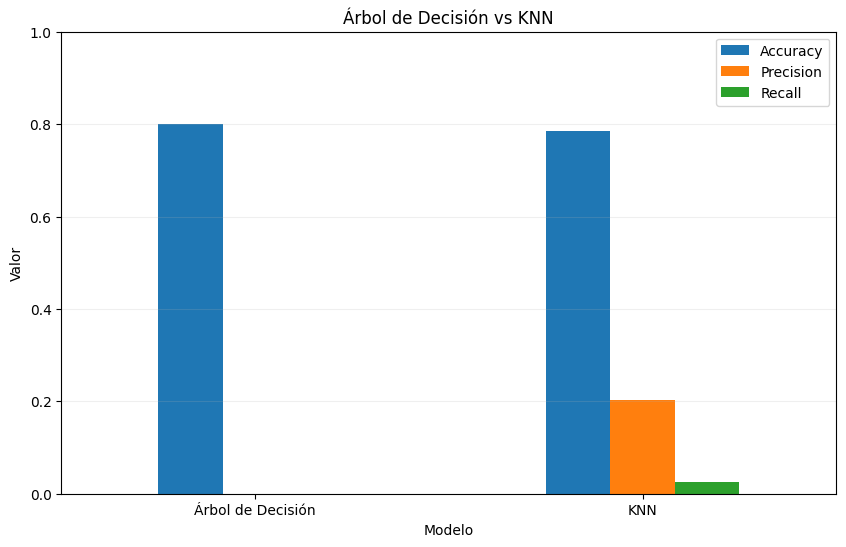

In [18]:
metricas = resultados.set_index("Modelo")[
 ["Accuracy", "Precision", "Recall"]
]
metricas.plot(
 kind="bar",
 figsize=(10,6),
 ylim=(0,1)
)
plt.title("Árbol de Decisión vs KNN")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.20)
plt.show()

Mide el porcentaje global de aciertos, pero es engañoso. Si el 95% de los datos no son de Toluca, el modelo puede tener 95% de Accuracy solo diciendo "Otro" siempre.

## Validación cruzada K-Fold

In [19]:
cv = StratifiedKFold(
 n_splits=5,
 shuffle=True,
 random_state=RANDOM_STATE
)
scoring = {
 "accuracy": "accuracy",
 "precision": "precision",
 "recall": "recall"
}
cv_arbol = cross_validate(
 arbol, X, y,
 cv=cv,
 scoring=scoring,
 n_jobs=-1
)
print("ÁRBOL")
for m in scoring:
 valores = cv_arbol["test_" + m]
 print(m,
 np.round(valores,4),
 "media =", valores.mean(),
 "desv =", valores.std())

ÁRBOL
accuracy [0.7996 0.7996 0.7996 0.7996 0.7996] media = 0.799646 desv = 1.999999999968693e-06
precision [0. 0. 0. 0. 0.] media = 0.0 desv = 0.0
recall [0. 0. 0. 0. 0.] media = 0.0 desv = 0.0


Precision responde "¿de todos los que etiquetaste como Toluca, cuántos sí lo eran?" (afectado directamente por los FP). Recall responde "¿de todos los Toluca reales, cuántos encontraste?" (afectado por los FN). Es muy probable que estas dos métricas sean bajas debido al desbalance de clases y al cruce de puntos.

In [21]:
n_muestra = 100000
n_pos = int(n_muestra * y.mean())
n_neg = n_muestra - n_pos
idx_pos = df_modelo[df_modelo["objetivo"]==1].sample(
 n=n_pos, random_state=RANDOM_STATE
).index
idx_neg = df_modelo[df_modelo["objetivo"]==0].sample(
 n=n_neg, random_state=RANDOM_STATE
).index
idx = idx_pos.union(idx_neg)
X_cv_knn = X.loc[idx]
y_cv_knn = y.loc[idx]
cv_knn = cross_validate(
 knn, X_cv_knn, y_cv_knn,
 cv=cv,
 scoring=scoring,
 n_jobs=-1
)
print("KNN")
for m in scoring:
 valores = cv_knn["test_" + m]
 print(m,
 np.round(valores,4),
 "media =", valores.mean(),
 "desv =", valores.std())

KNN
accuracy [0.7774 0.7786 0.7807 0.7784 0.7803] media = 0.7790699999999999 desv = 0.0012488394612599279
precision [0.1768 0.1881 0.1716 0.2028 0.2108] media = 0.1900192800074149 desv = 0.014910444406988578
recall [0.0304 0.0317 0.0247 0.0362 0.0352] media = 0.031644621911654604 desv = 0.004068417044634855


Entrenar y probar el modelo en 5 cortes o "folds" diferentes permite saber si el modelo es estable. Si los resultados promediados (media) se mantienen y la desviación estándar es muy baja, significa que el modelo se comporta igual sin importar qué pedazo de los datos vea.

# Archivo para Weka

In [24]:
weka_df = df[[
 "minuto_jugado",
 "pases_completados",
 "equipo"
]].copy()
weka_df["clase"] = np.where(
 weka_df["equipo"] == "Toluca",
 "Toluca",
 "Otro"
)
weka_df = weka_df[[
 "minuto_jugado",
 "pases_completados",
 "clase"
]]
weka_df.to_csv(
 "liga_mx_weka_clasificacion.csv",
 index=False
)
display(weka_df.head())
print(weka_df["clase"].value_counts())

,minuto_jugado,pases_completados,clase
0,22,34,Otro
1,63,27,Otro
2,1,18,Otro
3,71,27,Toluca
4,47,20,Toluca


clase
Otro      799646
Toluca    200354
Name: count, dtype: int64
